In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from rnn_models import RNN, make_windows
from plots import *

I0000 00:00:1790515163.100322 3906058 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Read in dataset

In [8]:
santa_fe_train = pd.read_csv("./Pre-processed datasets/Santa Fe/santa_fe_train_final.csv", index_col=0)
santa_fe_test = pd.read_csv("./Pre-processed datasets/Santa Fe/santa_fe_test_final.csv", index_col=0)

In [26]:
santa_fe_test

,intensity
0,0.282353
1,0.698039
2,0.478431
3,0.141176
4,0.054902
...,...
9088,0.145098
9089,0.113725
9090,0.137255
9091,0.235294


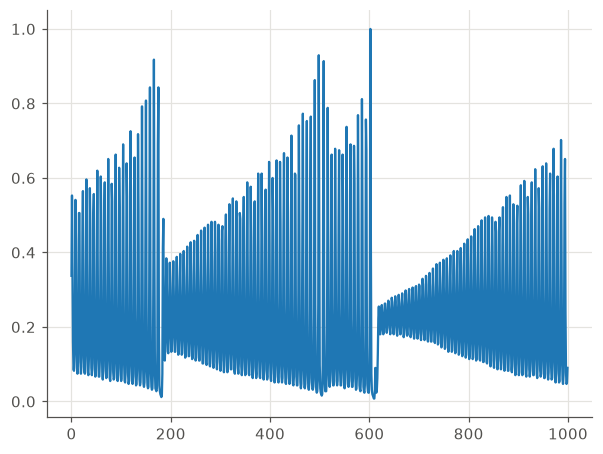

In [10]:
s = santa_fe_train["intensity"].to_numpy(dtype="float32")
plt.plot(s)
plt.show()

<Figure size 1100x660 with 0 Axes>

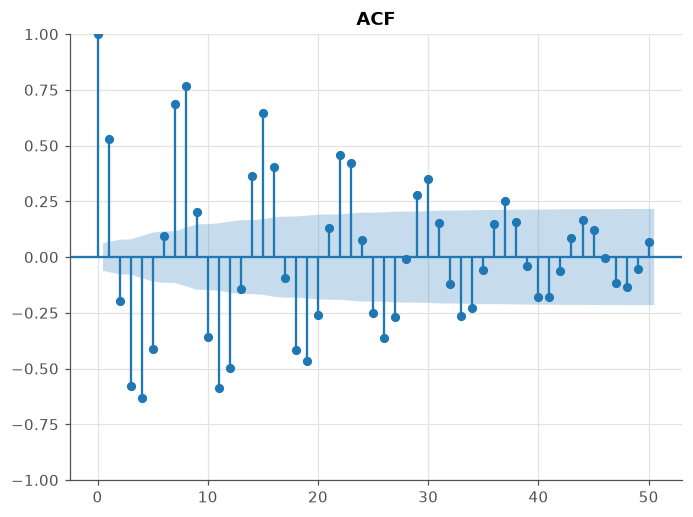

In [13]:
fig = plt.figure(figsize=(10, 6))
plot_acf(s, lags=50, title="ACF")
plt.tight_layout()
plt.show()

In [19]:
MAX_LAG = 8

# X: (n, 5, 1), y: (n,)
X_train, y_train = make_windows(s, MAX_LAG)
X_test, y_test = make_windows(santa_fe_test["intensity"].to_numpy(dtype="float32"), MAX_LAG)

## Elman: grid search using cross validation

In [18]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=40)

# Hyperparameters to search over.
param_grid_elman = {
    "lags": [4, 7, 8],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_elman = GridSearchCV(
    estimator=RNN(arch="elman"),
    param_grid=param_grid_elman,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1
)
grid_search_elman.fit(X_train, y_train)

# Retrieve the best model and parameters.
best_model_elman = grid_search_elman.best_estimator_
best_params_elman = grid_search_elman.best_params_
test_rmse_elman = np.sqrt(np.mean((best_model_elman.predict(X_test) - y_test) ** 2))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


I0000 00:00:1790515906.538624 3906058 gpu_device.cc:2036] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9514 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1790515907.992290 3906058 service.cc:154] XLA service 0x55c23faa55a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790515907.992303 3906058 service.cc:170]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.4.0[615.71.9]; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790515908.011481 3906058 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790515908.712352 3906058 cuda_dnn.cc:442] Loaded cuDNN version 92600
I0000 00:00:1790515908.982899 3906058 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


NameError: name 'X_test' is not defined

## Jordan: grid search using cross validation

In [20]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_jordan = {
    "lags": [4, 7, 8],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_jordan = GridSearchCV(
    estimator=RNN(arch="jordan"),
    param_grid=param_grid_jordan,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_jordan.fit(X_train, y_train)

# Retrieve the best model and parameters.
best_model_jordan = grid_search_jordan.best_estimator_
best_params_jordan = grid_search_jordan.best_params_
test_rmse_jordan = np.sqrt(np.mean((best_model_jordan.predict(X_test) - y_test) ** 2))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


## MRNN: grid search using cross validation

In [21]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_mrnn = {
    "lags": [4, 7, 8],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_mrnn = GridSearchCV(
    estimator=RNN(arch="mrnn"),
    param_grid=param_grid_mrnn,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_mrnn.fit(X_train, y_train)

# Retrieve the best model and parameters.
best_model_mrnn = grid_search_mrnn.best_estimator_
best_params_mrnn = grid_search_mrnn.best_params_
test_rmse_mrnn = np.mean((best_model_mrnn.predict(X_test) - y_test) ** 2)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [22]:
print(f"Test RMSE Elman: {test_rmse_elman}")
print(f"Test RMSE Jordan: {test_rmse_jordan}")
print(f"Test RMSE MRNN: {test_rmse_mrnn}")

NameError: name 'test_rmse_elman' is not defined

## Plots

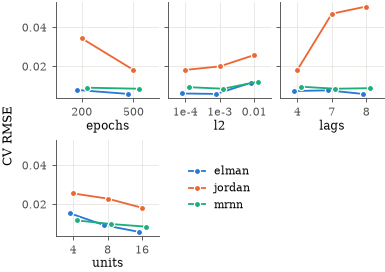

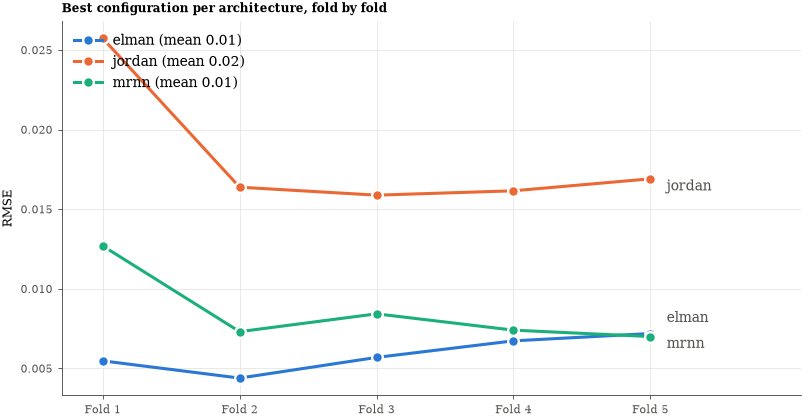

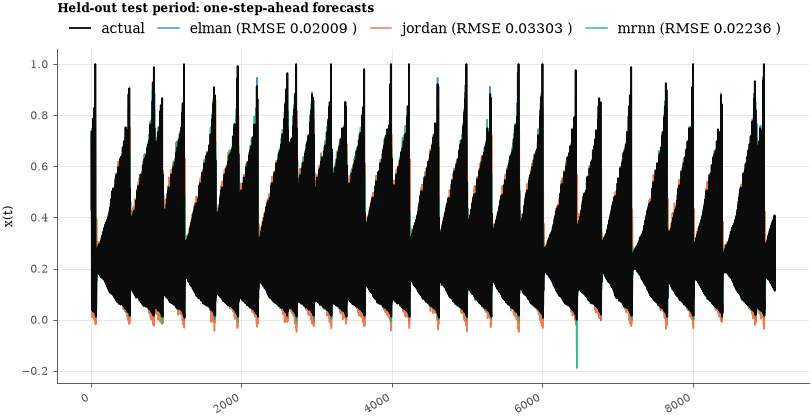

In [34]:
searches = {"elman": grid_search_elman, "jordan": grid_search_jordan, "mrnn": grid_search_mrnn}

set_units("", "x(t)")

ieee_style()

fig = plot_param_effects_all(searches, ncols=3, width=IEEE_COLUMN, title=False)
fig.savefig("./Results/Santa Fe/param_effects.pdf")
fig = plot_fold_comparison(searches)
fig.savefig("./Results/Santa Fe/fold_comparison.pdf")
fig = plot_test_forecast(searches, X_test, y_test, dates=santa_fe_test.index[MAX_LAG:])
fig.savefig("./Results/Santa Fe/test_forecast.pdf")

In [35]:
X_test.shape

(9085, 8, 1)

In [36]:
y_test.shape

(9085,)

## Testing best configurations on 5 different seeds

In [40]:
def seed_check(gs, X, y, cv, seeds=range(5)):
    rows = []
    for s in seeds:
        est = gs.best_estimator_.__class__(**{**gs.best_estimator_.get_params(), "seed": s})
        res = cross_validate(est, X, y, cv=cv, scoring="neg_root_mean_squared_error")
        rows.append(-res["test_score"])
    return np.array(rows)          # shape (n_seeds, n_folds)

In [41]:
def seed_tables(results, decimals=5):
    """
    results : {"elman": r_elman, "jordan": r_jordan, "mrnn": r_mrnn}
              each r is the (n_seeds, n_folds) array returned by seed_check.
    Returns three DataFrames: summary, per_seed, per_fold.
    """
    summary = pd.DataFrame({
        name: {
            "Mean CV RMSE": r.mean(),                          # r.mean()
            "Std across seeds": r.mean(axis=1).std(),           # r.mean(axis=1).std()
            "Best seed": r.mean(axis=1).min(),
            "Worst seed": r.mean(axis=1).max(),
        } for name, r in results.items()
    }).T

    per_seed = pd.DataFrame({name: r.mean(axis=1) for name, r in results.items()})   # r.mean(axis=1)
    per_seed.index = [f"Seed {s}" for s in range(len(per_seed))]

    per_fold = pd.DataFrame({name: r.mean(axis=0) for name, r in results.items()})   # r.mean(axis=0)
    per_fold.index = [f"Fold {f + 1}" for f in range(len(per_fold))]

    return summary.round(decimals), per_seed.round(decimals), per_fold.round(decimals)

In [42]:
results = {
    "elman": seed_check(grid_search_elman, X_train, y_train, cv),
    "jordan": seed_check(grid_search_jordan, X_train, y_train, cv),
    "mrnn": seed_check(grid_search_mrnn, X_train, y_train, cv),
}
summary, per_seed, per_fold = seed_tables(results)
summary.to_csv("./Results/Santa Fe/summary.csv")
per_seed.to_csv("./Results/Santa Fe/per_seed.csv")
per_fold.to_csv("./Results/Santa Fe/per_fold.csv")